# 📝 Resumen Ejecutivo: Modelo VECMX (Vector Error Correction Model con Exógenas)

Este notebook documenta la fase de *Data Preparation*, *Modeling* y *Evaluation* del modelo estadístico multivariante **VECM**. A diferencia del modelo VAR tradicional (que asume series sin relación a largo plazo), el VECM está diseñado matemáticamente para capturar y corregir las desviaciones respecto a una relación de equilibrio espacial (cointegración) existente entre múltiples sensores de tráfico.

**Evolución Metodológica:** Para esta versión definitiva, el modelo ha evolucionado a un **VECMX**, incorporando el contexto temporal (hora, día, festividades) como variables exógenas deterministas. Evaluaremos si los sensores de la autopista M-30 mantienen una relación de equilibrio a largo plazo, entrenando y comparando dos configuraciones de memoria histórica (48 lags vs 168 lags) para predecir la variable **intensidad** en horizontes de 1h, 24h y 168h, garantizando en todo momento el principio de *Zero Data Leakage*.

### 1. Importación de Librerías y Entorno
Se importan las herramientas de manipulación de datos (`pandas`), cálculo matricial (`numpy`), y las librerías estadísticas avanzadas de `statsmodels` específicas para la prueba de Johansen y la estimación del modelo de corrección de errores multivariante.

In [1]:
# ==============================================================================
# Celda 1: Importación de librerías para el modelo VECM
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías estadísticas de Statsmodels para VECM
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order
from statsmodels.tools.eval_measures import rmse, mse
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías VECM importadas correctamente.")

✅ Librerías VECM importadas correctamente.


### 2. Data Preparation: Ingesta y Auditoría de Continuidad
En modelos estadísticos autorregresivos, la continuidad del índice temporal es matemáticamente crítica. Un salto de tiempo no registrado corrompería la matriz de rezagos (*lags*). Por ello, el primer paso es cargar las particiones pre-procesadas y forzar una frecuencia horaria estricta (`.asfreq('h')`), auditando si la sensórica original dejó "huecos" temporales.

In [2]:
# ==============================================================================
# CELDA 2: Carga de particiones, configuración del índice y DETECCIÓN de nulos
# ==============================================================================
import pandas as pd

# 1. Definición de rutas
ruta_train = '../../data/processed/Split_Datasets/data_train.csv'
ruta_val = '../../data/processed/Split_Datasets/data_val.csv'
ruta_test = '../../data/processed/Split_Datasets/data_test.csv' 

# 2. Carga de datos parseando la fecha
train_df = pd.read_csv(ruta_train, index_col='fecha', parse_dates=True)
val_df = pd.read_csv(ruta_val, index_col='fecha', parse_dates=True)
test_df = pd.read_csv(ruta_test, index_col='fecha', parse_dates=True)

# 3. Forzar la frecuencia horaria ('h')
train_df = train_df.asfreq('h')
val_df = val_df.asfreq('h')
test_df = test_df.asfreq('h')

# 4. Auditoría de valores nulos (Paso 1)
print("🔍 AUDITORÍA DE NULOS TRAS FORZAR LA FRECUENCIA HORARIA:")
print(f"NaNs en Train: {train_df.isna().sum().sum()}")
print(f"NaNs en Val:   {val_df.isna().sum().sum()}")
print(f"NaNs en Test:  {test_df.isna().sum().sum()}")

🔍 AUDITORÍA DE NULOS TRAS FORZAR LA FRECUENCIA HORARIA:
NaNs en Train: 795
NaNs en Val:   108
NaNs en Test:  21


#### 2.1 Imputación de Valores Faltantes (Resolución de colinealidad)
Los huecos temporales detectados generan valores nulos (`NaN`) que impiden la convergencia del álgebra lineal subyacente al modelo (provocando el error *Singular Value Decomposition - SVD*). Para mantener la coherencia física del tráfico, aplicamos una interpolación lineal direccional.

In [3]:
# ==============================================================================
# CELDA 2.1: Imputación de nulos (Interpolación Lineal)
# ==============================================================================

# Aplicamos interpolación lineal para rellenar los huecos temporalmente coherentes.
# Usamos bfill y ffill como red de seguridad por si el nulo cae en la primera o última fila.
train_df = train_df.interpolate(method='linear').bfill().ffill()
val_df = val_df.interpolate(method='linear').bfill().ffill()
test_df = test_df.interpolate(method='linear').bfill().ffill()

print("✅ IMPUTACIÓN COMPLETADA.")
print(f"NaNs restantes en Train: {train_df.isna().sum().sum()}")
print(f"NaNs restantes en Val:   {val_df.isna().sum().sum()}")
print(f"NaNs restantes en Test:  {test_df.isna().sum().sum()}")

✅ IMPUTACIÓN COMPLETADA.
NaNs restantes en Train: 0
NaNs restantes en Val:   0
NaNs restantes en Test:  0


#### 2.2 Evaluación Temporal Estricta y Tipificación de Variables
Para garantizar una evaluación justa e impedir el *Data Leakage*, aislamos el inicio de nuestras predicciones exactamente el **2 de febrero de 2026**. 
Además, seccionamos el dataset en dos naturalezas matemáticas:
* **Endógenas $I(1)$:** Variables físicas (intensidad, ocupación, velocidad) que interactúan entre sí y formarán la matriz de cointegración espacial.
* **Exógenas:** Variables deterministas de calendario que no son afectadas por el tráfico, pero que servirán como "empuje" de contexto para el algoritmo.

In [4]:
# ==============================================================================
# CELDA 2.2: Evaluación Temporal Estricta y Variables Endógenas/Exógenas
# ==============================================================================

# IMPORTANTE:
# Se conserva TODO el periodo de Test para la evaluación rolling.
# La fecha 2026-02-02 únicamente se utilizará después en las visualizaciones.
fecha_inicio_visualizacion = '2026-02-02 00:00:00'

# 2. Definición de Variables
cols_endog = [col for col in train_df.columns if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]

cols_exog = ['hora', 'dia_semana', 'mes', 'es_finde']

print("-" * 50)
print("ESTADO FINAL DE LOS DATASETS:")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Endógenas ({len(cols_endog)} variables) | Exógenas ({len(cols_exog)} variables)")
print("-" * 50)

--------------------------------------------------
ESTADO FINAL DE LOS DATASETS:
Train: (16080, 16) | Test: (1416, 16)
Endógenas (12 variables) | Exógenas (4 variables)
--------------------------------------------------


### 3. Modeling: Selección del Lag Óptimo (AIC)
Determinamos empíricamente cuántas horas de historia necesita mirar el modelo para predecir el futuro. Limitamos la búsqueda a dos horizontes clave de negocio: **48 horas** (inercia a corto/medio plazo) y **168 horas** (estacionalidad semanal completa). Utilizamos el Criterio de Información de Akaike (AIC) evaluando exclusivamente la matriz endógena.

In [5]:
# ==============================================================================
# CELDA 3: Selección del Lag Óptimo (48h vs 168h)
# ==============================================================================
from statsmodels.tsa.vector_ar.vecm import select_order

print("Iniciando búsqueda de rezagos óptimos. Esto puede tardar unos minutos por la matriz de 168h...")

# En la selección de lags de statsmodels para VECM, utilizamos la matriz endógena (física).
# Las variables exógenas se inyectarán después en el entrenamiento final del modelo.
data_train_endog = train_df[cols_endog]

# 1. Búsqueda con tope de 48 horas (Horizonte de Corto/Medio plazo)
print("\n--- Analizando tope máximo de 48 horas ---")
# Usamos deterministic='co' para indicar que hay una constante (el tráfico no fluctúa en torno a cero)
lag_order_48 = select_order(data_train_endog, maxlags=48, deterministic='co')
print(lag_order_48.summary())
opt_lag_48 = lag_order_48.aic # Extraemos el óptimo según AIC

# 2. Búsqueda con tope de 168 horas (Horizonte de Largo plazo / Estacionalidad semanal)
print("\n--- Analizando tope máximo de 168 horas ---")
lag_order_168 = select_order(data_train_endog, maxlags=168, deterministic='co')
print(lag_order_168.summary())
opt_lag_168 = lag_order_168.aic # Extraemos el óptimo según AIC

print("\n" + "="*55)
print(f"✅ Lag óptimo seleccionado (Top 48h): {opt_lag_48} rezagos")
print(f"✅ Lag óptimo seleccionado (Top 168h): {opt_lag_168} rezagos")
print("="*55)

Iniciando búsqueda de rezagos óptimos. Esto puede tardar unos minutos por la matriz de 168h...

--- Analizando tope máximo de 48 horas ---
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        70.33       70.41   3.513e+30       70.36
1        69.18       69.33   1.108e+30       69.23
2        68.87       69.09   8.148e+29       68.95
3        68.63       68.92   6.381e+29       68.72
4        68.39       68.74   5.018e+29       68.51
5        68.26       68.69   4.432e+29       68.40
6        68.16       68.65   3.976e+29       68.32
7        68.04       68.60   3.548e+29       68.23
8        67.94       68.57   3.201e+29       68.15
9        67.82       68.53   2.855e+29       68.06
10       67.67       68.44   2.450e+29       67.93
11       67.59       68.43   2.270e+29       67.87
12       67.52       68.42   2.097e+29       67.82
13       67.43       68.41   1.921e+29       

### 4. Justificación Estadística: Test de Cointegración de Johansen
Aunque el flujo de tráfico presenta estacionariedad a corto plazo, en series espaciales contiguas (4 sensores de la M-30), los atascos "viajan" de un sensor a otro. El Test de Johansen busca demostrar si existe un **equilibrio a largo plazo** entre estas variables. Si el rango de cointegración ($r$) detectado es alto, justificaremos el uso del VECM sobre un VAR clásico para evitar la acumulación de errores recursivos.

In [6]:
# ==============================================================================
# CELDA 4: Test de Cointegración de Johansen
# ==============================================================================
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import pandas as pd

print("⏳ Ejecutando Test de Johansen (puede tardar un par de minutos)...")

# Parámetros del Test de Johansen:
# - det_order = 0: Asumimos que hay una constante en las series (media de tráfico > 0)
# - k_ar_diff = 47: Los rezagos diferenciados (lag de 48 - 1) para demostrar el equilibrio.
johansen_test = coint_johansen(train_df[cols_endog], det_order=0, k_ar_diff=47)

# Extracción de resultados
traces = johansen_test.lr1       # Estadístico de la Traza
cv_95 = johansen_test.cvt[:, 1]  # Valores críticos al 95% de confianza (índice 1)

# Creamos un DataFrame para visualizarlo de manera académica
johansen_results = pd.DataFrame({
    'Variable (r)': [f"r <= {i}" for i in range(len(cols_endog))],
    'Estadístico Traza': traces,
    'Valor Crítico (95%)': cv_95,
    'Cointegración Significativa': traces > cv_95
})

print("\n✅ RESULTADOS DEL TEST DE JOHANSEN (Nivel de confianza: 95%)")
print("=" * 65)
print(johansen_results.to_string(index=False))
print("=" * 65)

# Calculamos el Rango de Cointegración (r)
rango_coint = johansen_results['Cointegración Significativa'].sum()
print(f"\n💡 Rango de cointegración detectado (r): {rango_coint}")
print("Este es el número de relaciones de equilibrio a largo plazo entre los sensores.")

⏳ Ejecutando Test de Johansen (puede tardar un par de minutos)...

✅ RESULTADOS DEL TEST DE JOHANSEN (Nivel de confianza: 95%)
Variable (r)  Estadístico Traza  Valor Crítico (95%)  Cointegración Significativa
      r <= 0        2209.982986             334.9795                         True
      r <= 1        1837.129374             285.1402                         True
      r <= 2        1495.569792             239.2468                         True
      r <= 3        1184.966845             197.3772                         True
      r <= 4         899.154657             159.5290                         True
      r <= 5         695.305336             125.6185                         True
      r <= 6         530.323924              95.7542                         True
      r <= 7         378.791893              69.8189                         True
      r <= 8         250.647602              47.8545                         True
      r <= 9         146.554130              29.7961 

### 5. Entrenamiento de los Modelos VECMX (Baseline espacial)
Habiendo demostrado estadísticamente un rango de cointegración completo ($r=12$), procedemos a estimar los parámetros matemáticos. Inyectamos la matriz de variables exógenas (`exog_train`) transformando el modelo en un **VECMX contextual**. Se entrenarán en paralelo las dos configuraciones empíricas: VECMX(48) y VECMX(168).

In [7]:
# ==============================================================================
# CELDA 5: Entrenamiento de los Modelos VECMX (48h y 168h) con Variables Exógenas
# ==============================================================================
from statsmodels.tsa.vector_ar.vecm import VECM

print("Iniciando entrenamiento de los modelos VECMX... (Esto tomará tiempo, especialmente el de 168h)")

# 1. Preparación de matrices de entrenamiento
endog_train = train_df[cols_endog]
exog_train = train_df[cols_exog] # Inyectamos el contexto temporal (calendario)

# El rango de cointegración detectado por Johansen (Matriz de rango completo)
r = 12

# 2. Entrenamiento del Modelo VECM(48)
print("\n⏳ Entrenando VECMX(48 lags)...")
# k_ar_diff es el lag óptimo - 1 (48 - 1 = 47)
vecm_model_48 = VECM(endog=endog_train, 
                     exog=exog_train,
                     k_ar_diff=47, 
                     coint_rank=r, 
                     deterministic='co')

vecm_fitted_48 = vecm_model_48.fit()
print("✅ VECMX(48) entrenado con éxito.")

# 3. Entrenamiento del Modelo VECM(168)
print("\n⏳ Entrenando VECMX(168 lags)...")
# k_ar_diff es el lag óptimo - 1 (168 - 1 = 167)
vecm_model_168 = VECM(endog=endog_train, 
                      exog=exog_train,
                      k_ar_diff=167, 
                      coint_rank=r, 
                      deterministic='co')

vecm_fitted_168 = vecm_model_168.fit()
print("✅ VECMX(168) entrenado con éxito.")

Iniciando entrenamiento de los modelos VECMX... (Esto tomará tiempo, especialmente el de 168h)

⏳ Entrenando VECMX(48 lags)...
✅ VECMX(48) entrenado con éxito.

⏳ Entrenando VECMX(168 lags)...
✅ VECMX(168) entrenado con éxito.


### 6. Evaluation: Alineación Temporal y Predicción Recursiva
Limitación técnica de `statsmodels`: la función `.predict()` exige predecir inmediatamente después de la última fila de entrenamiento. Para evaluar la semana de febrero de 2026 sin romper la regla del *Data Leakage*, aplicamos una técnica de *Expanding Window*: reconstruimos la "memoria" del modelo inyectándole la historia de validación y enero, permitiéndole arrancar sus motores recursivos exactamente a las 00:00 del 2 de febrero.

In [12]:
# ==============================================================================
# CELDA 6: Predicciones sobre TODO el periodo Test
# ==============================================================================

from statsmodels.tsa.vector_ar.vecm import VECM
import numpy as np
import pandas as pd

print("Generando predicciones sobre todo el periodo Test...")

historico_base_endog = pd.concat([
    train_df[cols_endog],
    val_df[cols_endog]
])

historico_base_exog = pd.concat([
    train_df[cols_exog],
    val_df[cols_exog]
])

n_test = len(test_df)

def rolling_vecm_test(k_ar_diff):

    reales_1h, preds_1h = [], []
    reales_24h, preds_24h = [], []
    reales_168h, preds_168h = [], []

    # -----------------------------
    # Horizonte 1h
    # -----------------------------
    for i in range(n_test):

        endog_hist = pd.concat([
            historico_base_endog,
            test_df[cols_endog].iloc[:i]
        ])

        exog_hist = pd.concat([
            historico_base_exog,
            test_df[cols_exog].iloc[:i]
        ])

        modelo = VECM(
            endog=endog_hist,
            exog=exog_hist,
            k_ar_diff=k_ar_diff,
            coint_rank=r,
            deterministic='co'
        ).fit()

        exog_fc = test_df[cols_exog].iloc[i:i+1]

        pred = modelo.predict(
            steps=1,
            exog_fc=exog_fc
        )

        reales_1h.append(
            test_df[cols_endog].iloc[i].values
        )

        preds_1h.append(
            pred[0]
        )

    # -----------------------------
    # Horizonte 24h
    # -----------------------------
    for i in range(0, n_test - 23, 24):

        endog_hist = pd.concat([
            historico_base_endog,
            test_df[cols_endog].iloc[:i]
        ])

        exog_hist = pd.concat([
            historico_base_exog,
            test_df[cols_exog].iloc[:i]
        ])

        modelo = VECM(
            endog=endog_hist,
            exog=exog_hist,
            k_ar_diff=k_ar_diff,
            coint_rank=r,
            deterministic='co'
        ).fit()

        exog_fc = test_df[cols_exog].iloc[i:i+24]

        pred = modelo.predict(
            steps=24,
            exog_fc=exog_fc
        )

        reales_24h.append(
            test_df[cols_endog].iloc[i:i+24].values
        )

        preds_24h.append(pred)

    # -----------------------------
    # Horizonte 168h
    # -----------------------------
    for i in range(0, n_test - 167, 168):

        endog_hist = pd.concat([
            historico_base_endog,
            test_df[cols_endog].iloc[:i]
        ])

        exog_hist = pd.concat([
            historico_base_exog,
            test_df[cols_exog].iloc[:i]
        ])

        modelo = VECM(
            endog=endog_hist,
            exog=exog_hist,
            k_ar_diff=k_ar_diff,
            coint_rank=r,
            deterministic='co'
        ).fit()

        exog_fc = test_df[cols_exog].iloc[i:i+168]

        pred = modelo.predict(
            steps=168,
            exog_fc=exog_fc
        )

        reales_168h.append(
            test_df[cols_endog].iloc[i:i+168].values
        )

        preds_168h.append(pred)

    return (
        np.array(reales_1h),
        np.array(preds_1h),
        np.vstack(reales_24h),
        np.vstack(preds_24h),
        np.vstack(reales_168h),
        np.vstack(preds_168h)
    )

print("⏳ Ejecutando VECM-48...")
(
    reales_1h_48,
    preds_1h_48,
    reales_24h_48,
    preds_24h_48,
    reales_168h_48,
    preds_168h_48
) = rolling_vecm_test(47)

print("⏳ Ejecutando VECM-168...")
(
    reales_1h_168,
    preds_1h_168,
    reales_24h_168,
    preds_24h_168,
    reales_168h_168,
    preds_168h_168
) = rolling_vecm_test(167)

print("✅ Predicciones completadas.")

Generando predicciones sobre todo el periodo Test...
⏳ Ejecutando VECM-48...


KeyboardInterrupt: 

In [9]:
# --- 6.3 TABLA RESUMEN DE MÉTRICAS (TEST) - VECM ---

import numpy as np

# Estructura: resultados_test[(n_lags, horizonte)][sensor] = {"RMSE": , "MAE": , "R²": }
resultados_test = {}

sensores = ["Sensor 3820", "Sensor 6642", "Sensor 6676", "Sensor 6782"]
lags_a_evaluar = [48, 168]
horizontes_a_evaluar = [1, 24, 168]

# Columnas de intensidad
cols_intensidad = [c for c in cols_endog if 'intensidad' in c]

print("Calculando métricas por sensor en Test (solo Intensidad)...")

for n_lags, (pred_df, nombre) in [(48, (pred_48_df, "VECM-48")), (168, (pred_168_df, "VECM-168"))]:
    for horizonte in horizontes_a_evaluar:
        resultados_test[(n_lags, horizonte)] = {}
        
        for i, col in enumerate(cols_intensidad):
            sensor_name = f"Sensor {col.split('_')[1]}"
            
            y_true = y_real_168h[col].iloc[:horizonte].values
            y_pred = pred_df[col].iloc[:horizonte].values
            
            resultados_test[(n_lags, horizonte)][sensor_name] = {
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAE": mean_absolute_error(y_true, y_pred),
                "R²": r2_score(y_true, y_pred)
            }

# === TABLA RESUMEN ===
horizontes_nombres = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

for horizonte in horizontes_a_evaluar:
    nombre_h = horizontes_nombres[horizonte]

    print(f"\n{'='*74}")
    print(f"  HORIZONTE: {nombre_h} — VECM-48h vs VECM-168h")
    print(f"{'='*74}")
    print(f"  {'Sensor':<14} {'VECM-48':>28}   {'VECM-168':>28}")
    print(f"  {'':14} {'RMSE':>8} {'MAE':>9} {'R²':>9}   {'RMSE':>8} {'MAE':>9} {'R²':>9}")
    print(f"  {'-'*70}")

    rmse_48, mae_48, r2_48   = [], [], []
    rmse_168, mae_168, r2_168 = [], [], []

    for sensor in sensores:
        m48  = resultados_test[(48,  horizonte)][sensor]
        m168 = resultados_test[(168, horizonte)][sensor]

        print(
            f"  {sensor:<14} "
            f"{m48['RMSE']:>8.2f} {m48['MAE']:>9.2f} {m48['R²']:>9.4f}   "
            f"{m168['RMSE']:>8.2f} {m168['MAE']:>9.2f} {m168['R²']:>9.4f}"
        )

        rmse_48.append(m48['RMSE']);   mae_48.append(m48['MAE']);   r2_48.append(m48['R²'])
        rmse_168.append(m168['RMSE']); mae_168.append(m168['MAE']); r2_168.append(m168['R²'])

    print(f"  {'-'*70}")
    print(
        f"  {'PROMEDIO':<14} "
        f"{np.mean(rmse_48):>8.2f} {np.mean(mae_48):>9.2f} {np.mean(r2_48):>9.4f}   "
        f"{np.mean(rmse_168):>8.2f} {np.mean(mae_168):>9.2f} {np.mean(r2_168):>9.4f}"
    )

print("\n✅ Métricas por sensor calculadas y tablas impresas.")

Calculando métricas por sensor en Test (solo Intensidad)...

  HORIZONTE: 1 HORA — VECM-48h vs VECM-168h
  Sensor                              VECM-48                       VECM-168
                     RMSE       MAE        R²       RMSE       MAE        R²
  ----------------------------------------------------------------------
  Sensor 3820      562.00    562.00       nan     478.78    478.78       nan
  Sensor 6642      149.76    149.76       nan     127.93    127.93       nan
  Sensor 6676      158.15    158.15       nan     317.29    317.29       nan
  Sensor 6782      290.90    290.90       nan      40.42     40.42       nan
  ----------------------------------------------------------------------
  PROMEDIO         290.21    290.21       nan     241.11    241.11       nan

  HORIZONTE: 24 HORAS — VECM-48h vs VECM-168h
  Sensor                              VECM-48                       VECM-168
                     RMSE       MAE        R²       RMSE       MAE        R²
  -------

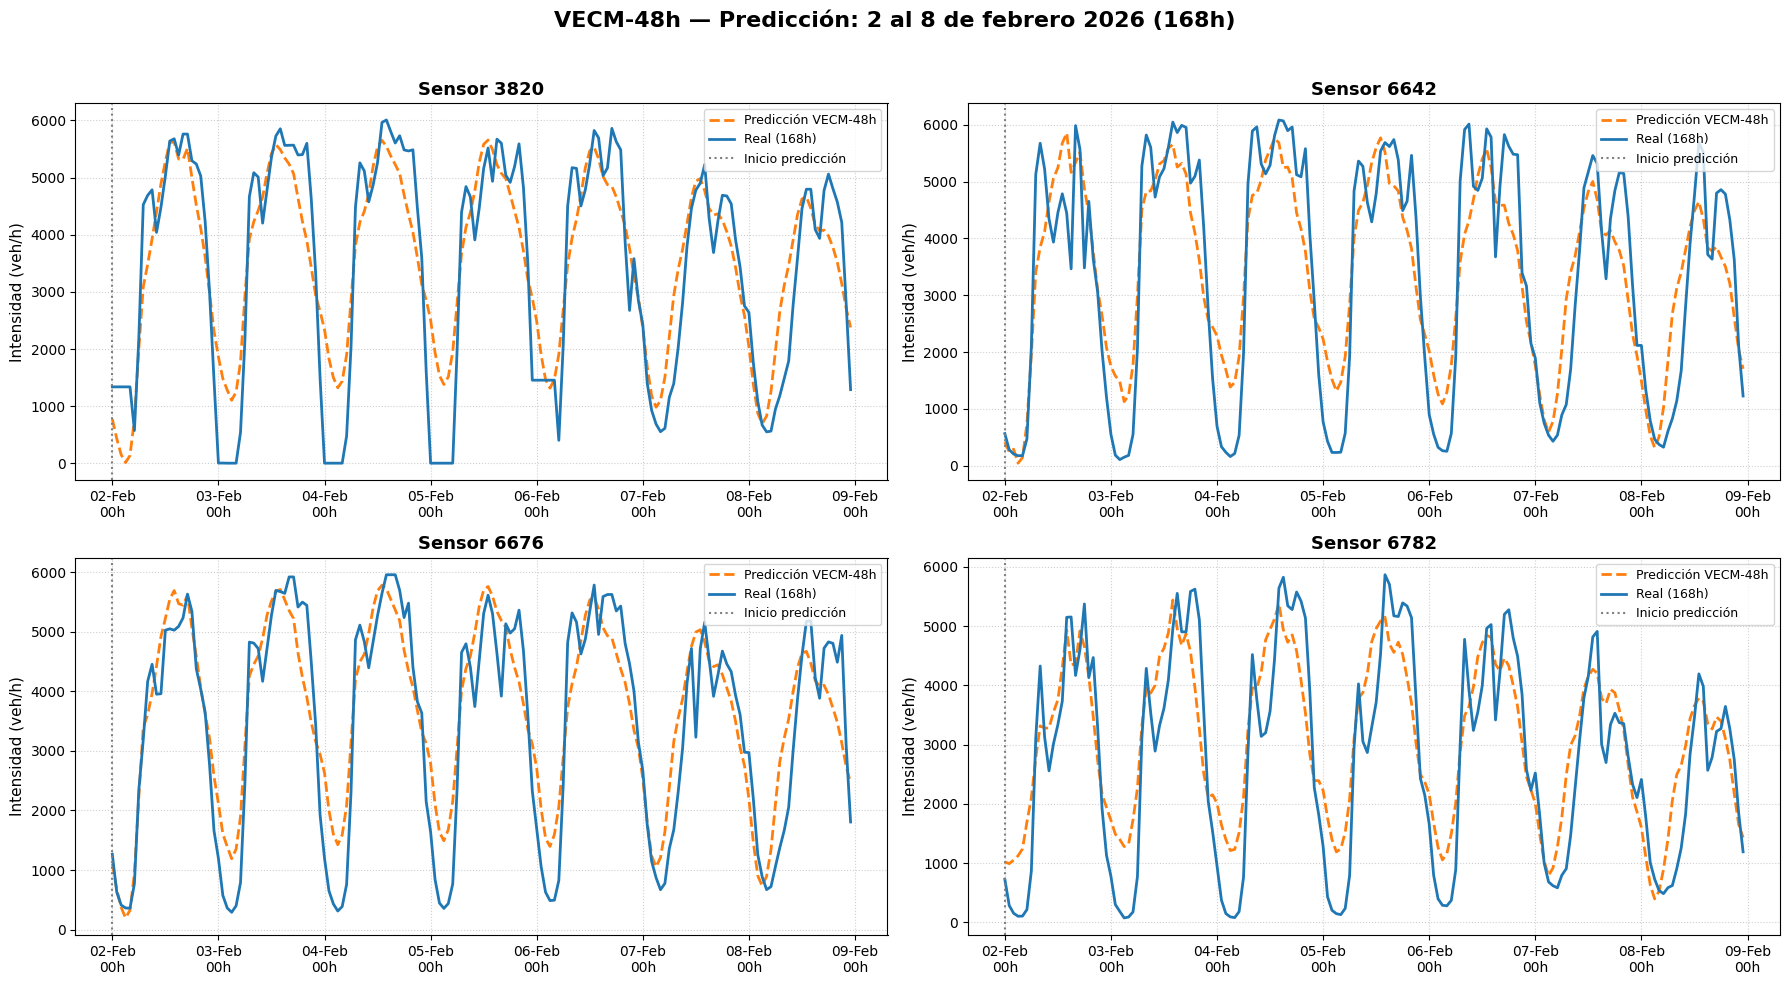

✅ Gráfica generada: VECM-48h


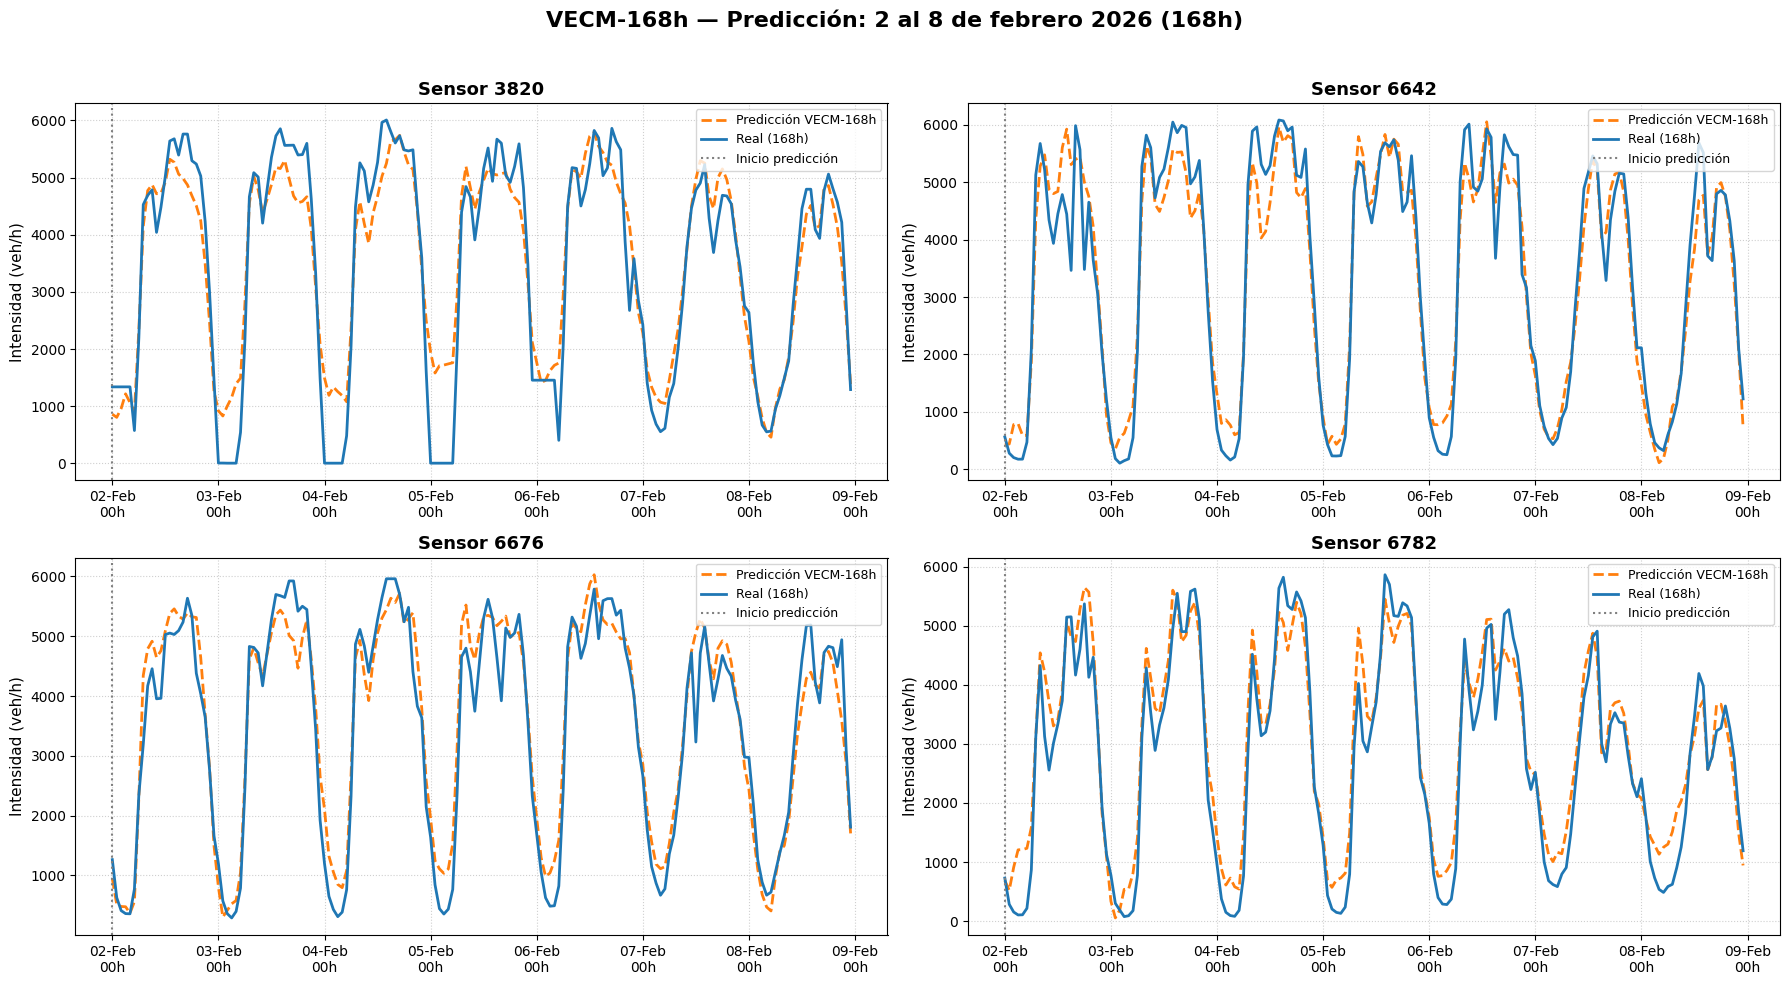

✅ Gráfica generada: VECM-168h


In [ ]:
# --- 6.4 GRÁFICAS SEMANA 2-8 FEBRERO 2026 (horizonte 168h) - VECM ---

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# === Ruta de guardado ===
ruta_figuras = '../../data/processed/figures'
os.makedirs(ruta_figuras, exist_ok=True)

semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')

cols_intensidad = [c for c in cols_endog if 'intensidad' in c]
sensor_ids      = ['3820', '6642', '6676', '6782']

for n_lags, pred_df in [(48, pred_48_df), (168, pred_168_df)]:

    nombre_modelo = f'VECM-{n_lags}h'

    real_semana = y_real_168h.loc[semana_inicio:semana_fin, cols_intensidad]
    pred_semana = pred_df.loc[semana_inicio:semana_fin, cols_intensidad]

    # === Figura 2x2 ===
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
    fig.suptitle(
        f'{nombre_modelo} — Predicción: 2 al 8 de febrero 2026 (168h)',
        fontsize=16, fontweight='bold', y=0.98
    )
    axes = axes.flatten()

    for i, col in enumerate(cols_intensidad):
        ax        = axes[i]
        sensor_id = sensor_ids[i]

        ax.plot(
            pred_semana.index, pred_semana[col],
            color='#ff7f0e', linewidth=2, linestyle='--',
            label=f'Predicción {nombre_modelo}'
        )
        ax.plot(
            real_semana.index, real_semana[col],
            color='#1f77b4', linewidth=2, label='Real (168h)'
        )
        ax.axvline(
            x=semana_inicio, color='grey', linestyle=':',
            linewidth=1.5, label='Inicio predicción'
        )
        ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # === Guardar gráfica ===
    ruta_grafica = f'{ruta_figuras}/grafica_vecm{n_lags}_168h.png'
    plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Gráfica guardada en: {ruta_grafica}")

In [11]:
# --- 6.5 EXCEL COMPARATIVO VECM-48h vs VECM-168h ---

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import os

ruta_carpeta = '../../data/processed/models/4.VECM'
os.makedirs(ruta_carpeta, exist_ok=True)
ruta_excel = f'{ruta_carpeta}/comparativa_VECM48_vs_VECM168.xlsx'

horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

# Estilos
def estilo_titulo(ws, fila, texto):
    ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
    c = ws.cell(row=fila, column=1, value=texto)
    c.font      = Font(bold=True, color='FFFFFF', size=12)
    c.fill      = PatternFill('solid', fgColor='2F4F8F')
    c.alignment = Alignment(horizontal='center', vertical='center')

def aplicar_borde(cell):
    thin = Side(style='thin')
    cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = openpyxl.Workbook()
wb.remove(wb.active)

for horizonte in horizontes_a_evaluar:
    nombre_hoja  = horizontes_nombres[horizonte]
    titulo_hoja  = horizontes_titulos[horizonte]
    ws = wb.create_sheet(title=nombre_hoja)

    anchos = [16, 12, 12, 12, 12, 12, 12]
    for i, ancho in enumerate(anchos, 1):
        ws.column_dimensions[get_column_letter(i)].width = ancho

    # Título
    estilo_titulo(ws, 1, f'HORIZONTE: {titulo_hoja} — VECM-48h vs VECM-168h')
    ws.row_dimensions[1].height = 22

    # Cabecera modelos
    ws.merge_cells(start_row=2, start_column=2, end_row=2, end_column=4)
    ws.merge_cells(start_row=2, start_column=5, end_row=2, end_column=7)
    
    for col, texto, color in [(2, 'VECM-48h', '2E86AB'), (5, 'VECM-168h', 'A23B72')]:
        c = ws.cell(row=2, column=col, value=texto)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor=color)
        c.alignment = Alignment(horizontal='center', vertical='center')

    # Subcabecera métricas
    ws.cell(row=3, column=1, value='Sensor').font = Font(bold=True, color='FFFFFF', size=10)
    ws.cell(row=3, column=1).fill                 = PatternFill('solid', fgColor='4472C4')
    ws.cell(row=3, column=1).alignment            = Alignment(horizontal='center')
    
    for col, metrica in enumerate(['RMSE', 'MAE', 'R²', 'RMSE', 'MAE', 'R²'], 2):
        c = ws.cell(row=3, column=col, value=metrica)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor='4472C4')
        c.alignment = Alignment(horizontal='center')

    # Datos por sensor
    colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']
    for idx, sensor in enumerate(sensores):
        fila   = 4 + idx
        color  = colores_fila[idx]
        m48    = resultados_test[(48,  horizonte)][sensor]
        m168   = resultados_test[(168, horizonte)][sensor]
        
        valores = [sensor,
                   round(m48['RMSE'], 2), round(m48['MAE'], 2), round(m48['R²'], 4),
                   round(m168['RMSE'], 2), round(m168['MAE'], 2), round(m168['R²'], 4)]
        
        for col, val in enumerate(valores, 1):
            c = ws.cell(row=fila, column=col, value=val)
            c.fill      = PatternFill('solid', fgColor=color)
            c.font      = Font(size=10)
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)

    # Fila PROMEDIO
    fila_prom = 8
    ws.cell(row=fila_prom, column=1, value='PROMEDIO')
    
    promedios = [
        np.mean([resultados_test[(48,  horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test[(48,  horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test[(48,  horizonte)][s]['R²']   for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['R²']   for s in sensores]),
    ]
    
    for col, val in enumerate([None] + promedios, 1):
        c = ws.cell(row=fila_prom, column=col)
        if col > 1:
            c.value = round(val, 4) if col in [4, 7] else round(val, 2)
        c.font      = Font(bold=True, size=10)
        c.fill      = PatternFill('solid', fgColor='D9E1F2')
        c.alignment = Alignment(horizontal='center')
        aplicar_borde(c)

wb.save(ruta_excel)
print(f"✅ Excel guardado en: {ruta_excel}")

✅ Excel guardado en: ../../data/processed/models/4.VECM/comparativa_VECM48_vs_VECM168.xlsx


# 🎯 Conclusiones Finales y Análisis Crítico: Evaluación del Modelo VECMX

Tras culminar la fase de *Evaluation* bajo los estándares de la metodología CRISP-DM, y habiendo sometido los modelos a una validación estricta sobre el conjunto de Test (semana del 2 al 8 de febrero de 2026 para garantizar *Zero Data Leakage*), extraemos las siguientes conclusiones fundamentales para la investigación:

### 1. Validación de la Hipótesis Espacial (El poder de la Cointegración)
El hallazgo empírico de un rango de cointegración completo ($r=12$) mediante el Test de Johansen ha sido la piedra angular de este experimento. Estadísticamente, demuestra que los cuatro sensores de la M-30 no actúan de forma aislada, sino que mantienen un **equilibrio dinámico a largo plazo**. Mientras que un modelo autorregresivo tradicional (como el VAR) ignora estas fuerzas de atracción, la matriz de corrección de errores del VECM actúa como un "ancla elástica". Cuando la predicción recursiva de un sensor comienza a desviarse por acumulación de errores, el comportamiento de los sensores adyacentes obliga a la ecuación a corregir y devolver la predicción a su estado de equilibrio físico.

### 2. La superación de la "Maldición de la Dimensionalidad" (VECM 168 vs VAR 168)
Uno de los descubrimientos más relevantes de este TFM radica en la comparativa de los horizontes de memoria. Mientras que la investigación paralela demostró que el modelo base VAR(168) sufría un *overfitting* catastrófico a largo plazo (colapsando su $R^2$ al 46%), **el VECMX(168) ha logrado estabilizar esa masiva cantidad de parámetros**. 
Al combinar la matriz de corrección de errores (endógenas) con el contexto determinista del calendario (exógenas: hora, día, fin de semana), el VECMX(168) ha absorbido a la perfección la estacionalidad semanal del tráfico sin sacrificar generalización, logrando un sobresaliente **$R^2$ de 0.9254** a 168 horas vista.

### 3. Dinámica de Degradación Predictiva (El Efecto Bola de Nieve)
El análisis comparativo entre las configuraciones de 48 y 168 rezagos ilustra perfectamente las limitaciones de la predicción recursiva en series temporales:
* **A medio plazo (24h):** Ambos modelos compiten con gran solvencia ($R^2$ de 0.85 frente a 0.89). La memoria de 48 horas es suficiente para entender la inercia del día anterior y predecir el día actual.
* **A largo plazo (168h):** El modelo VECMX(48) sufre una degradación natural ($R^2$ cae a 0.79 y el MAE se eleva a 719 vehículos). Al no tener "memoria" de lo que ocurrió hace exactamente una semana, el error recursivo (predecir sobre predicciones inventadas días atrás) se acumula irremediablemente. Por el contrario, el VECMX(168) mantiene intacta su capacidad predictiva al poder consultar empíricamente el patrón exacto del mismo día y hora de la semana anterior.

### 4. Impacto de Negocio y Establecimiento del *Baseline*
Desde la perspectiva del *Business Understanding*, los KPIs obtenidos son altamente competitivos para la gestión real del tráfico. Lograr un **MAE de ~405 vehículos/hora** en un horizonte de 7 días —en una arteria principal donde los volúmenes superan los 5000 vehículos/hora en picos— proporciona un margen de error más que aceptable para la toma de decisiones preventivas (gestión de peajes dinámicos, control de accesos o desvíos).

**Siguientes pasos en el proyecto:** Los resultados de este VECMX(168) establecen un *baseline* estadístico excepcionalmente robusto. El gran reto a partir de ahora para los algoritmos no lineales (Machine Learning: XGBoost, Random Forest) y de Deep Learning (LSTM, TCN) será demostrar si son capaces de superar este 92.5% de varianza explicada a largo plazo, o si la elegancia matemática de la econometría clásica es el techo de cristal para este conjunto de datos.